# ¿Que es un RAG?

Por definición es Generación Aumentada por Recuperación

A fines practicos, es una tecnica que permite ampliar la base de conocimiento del LLM.

Hay varias formas para lograr esta tarea, en el archivo anterior vimos la busqueda en linea para ampliar la base de conocimientos del modelo, en terminos generales los RAG funcionan con ese mismo concepto, algunas tecnicas son mas populares y utilizadas que otras.

---------

## 📊 Comparativa de tipos de consulta en sistemas tipo RAG

| Tipo de consulta | ¿Es RAG? | Cómo funciona | Ventajas | Desventajas | Cuándo usarlo |
|------------------|---------|--------------|----------|-------------|---------------|
| ❌ Prompt fijo | No | Todo el conocimiento está en el prompt | Simple, rápido | No escala, no dinámico | Demos o lógica muy acotada |
| 🔤 Búsqueda por keywords (BM25) | Sí | Busca coincidencias exactas de palabras | Rápido, interpretable | No entiende semántica | Documentos estructurados o legales |
| 🧾 Regex / reglas | Sí (limitado) | Extrae info con patrones | Muy preciso | Frágil, poco flexible | Facturas, CUIT, fechas |
| 🗄️ SQL / Base estructurada | Sí | Consulta datos tabulares | Exactitud alta | No sirve para texto libre | Sistemas administrativos |
| 🌐 APIs externas | Sí | Consulta servicios externos | Datos actualizados | Depende de terceros | Clima, precios, etc. |
| 🧠 Base vectorial (embeddings) | Sí (RAG moderno) | Busca similitud semántica | Flexible, potente | Más complejidad | Texto largo, PDFs, conocimiento |
| ⚡ Híbrido (BM25 + embeddings) | Sí | Combina keyword + semántica | Mejor recall/precision | Más complejo | Sistemas productivos |
| 🧩 Graph / knowledge graph | Sí | Navega relaciones entre entidades | Muy preciso en relaciones | Difícil de construir | Datos muy conectados |

---------

El caso de API externa es el que vimos en el documento anterior, el mismo metodo se podria haber utilizado para darle al modelo otros tipos de datos ya sea desde una API de clima, resultados deportivos, finanzas, etc.

Vamos a ir viendo superficialmente las otras opciones y luego haremos un sistema simple con Regex, dejaremos la tecnica de base vectorial para mas adelante donde veremos paso a paso como se conforma una base vectorial (el concepto posterior a esa etapa va a ser el mismo que todos los otros).

- **SQL**
> Pensando que tenemos una base de datos SQL o NoSQL sobre la cual consultar datos podemos usar un modelo LLM para convertir el input en lenguaje natural del usuario en codigo SQL que sirva para la busqueda en el motor de la base de datos.

Hay distintos formas de encarar esta situación, incluso hay herramientas de cloud (Ej: Azure AI Search) que resuelven casi completamente estas problematicas.

Las dos formas que vamos a mencionar aqui son:

> Consulta SQL con query parametrizada

> Consulta SQL con query generada por LLM

Para el primer caso, usando una query parametrizada, vamos a tener un query previamente armado como por ejemplo


```
Select dato_1, dato_2, dato_3 from Table NombredeTabla1 Where dato_x == {{dato_x}}
```

Los registros de salida los ingresamos luego en el contexto del modelo mediante el prompt y podremos hacer las consultas de contexto ampliado usando las bases de datos que nosotros necesitemos.

Para obtener los datos necesarios para el filtrado como por ejemplo dato_x podemos previamente hacer una llamada a un modelo LLM con un prompt que nos extraiga este dato especifico sobre el input en lenguaje natural. Por ejemplo:

```
Eres un asistente que extrae parámetros estructurados desde consultas en lenguaje natural.

Tu tarea es identificar el valor de **dato_x** a partir del texto del usuario.

### Instrucciones:

* Devuelve únicamente un JSON válido
* No agregues explicaciones
* Si no encuentras el valor, devuelve null
* Sé preciso y evita inferencias innecesarias

### Formato de salida:

```json
{
"dato_x": "valor_extraido"
}


### Ejemplos:

Consulta: "Quiero ver las facturas del cliente Juan Perez"
Salida:

```json
{
"dato_x": "Juan Perez"
}


Consulta: "Mostrame los registros del cliente ACME del mes pasado"
Salida:

```json
{
"dato_x": "ACME"
}


Consulta: "Dame todos los datos disponibles"
Salida:

```json
{
"dato_x": null
}


### Consulta del usuario:

{{input_usuario}}

```

-------------------

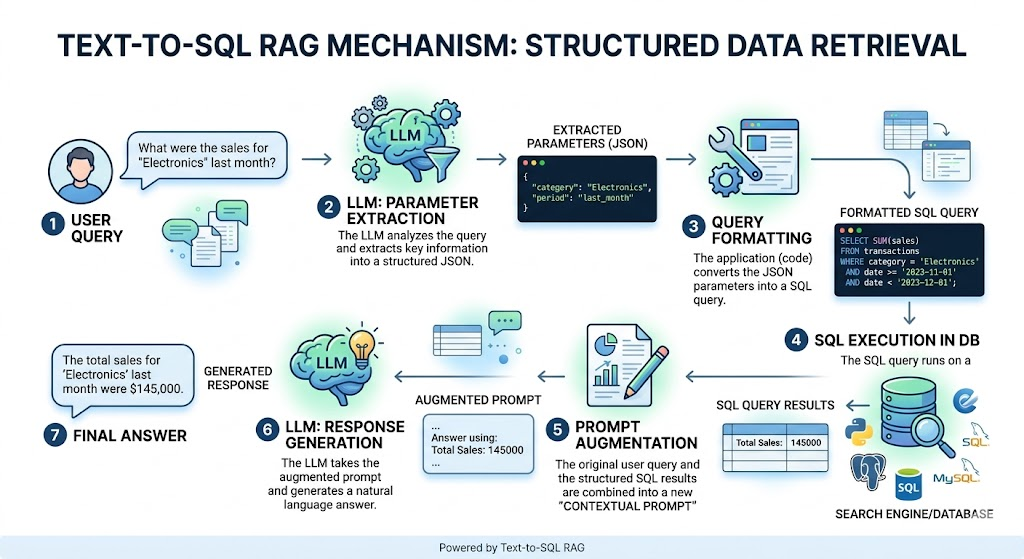

La ventaja de esta tecnica es que es menor la posibilidad de errores por alucinación o mal estructurado de la consulta por parte del LLM, si bien el modelo puede cometer errores, es mucho mas facil hacer un trakking y control de errores sobre output puntuales con formatos de salidas conocidos y esperados.

La otra opción es utilizar un modelo de LLM para el armado completo de la consulta, esto si bien le da mas versatilidad y flexibilidad a las información que traemos desde el motor sql, en contra partida es mas factible que el LLM nos devuelva una query en SQL con errores, y de ser asi es mucho mas complejo validar en donde estuvo el error del armado de la consulta.


Lo primero que necesitamos para usar esta tecnica es tener los datos de la estructura de datos de la base de datos en formato que podamos pasarlo como contexto al modelo que se encargara de interpretar el pedido del usuario y que cree una consulta que traiga los datos que puedan ser de utilidad para luego refinar o mejorar la información devuelta.

Los datos que deberian estar en el contexto
>Nombres exactos de las tablas y columnas.

>Tipos de datos (entero, texto, fecha).

>Relaciones (Claves primarias y foráneas) para que el modelo sepa cómo hacer los JOIN.

>Descripciones o comentarios sobre qué significa cada columna (mejora la interpretación del modelo).


Un ejemplo de como podria quedar el prompt que estariamos pasando para el armado del SQL
-------------------



```

CONTESTA ÚNICAMENTE CON LA QUERY SQL. NO AGREGUES EXPLICACIONES, TEXTO EXTRA NI FORMATO MARKDOWN (COMO ```sql).

[ROL]
Sos un experto en bases de datos PostgreSQL. Tu tarea es traducir la pregunta en lenguaje natural de un usuario a una consulta SQL válida, eficiente y segura utilizando estrictamente el esquema proporcionado a continuación.

[CONTEXTO DEL ESQUEMA]
Tenés acceso a las siguientes tablas y columnas de la base de datos:

1. Tabla: clientes
   - id_cliente (INT, Primary Key)
   - nombre (VARCHAR)
   - ciudad (VARCHAR)
   - fecha_registro (DATE)

2. Tabla: ventas
   - id_venta (INT, Primary Key)
   - id_cliente (INT, Foreign Key -> clientes.id_cliente)
   - fecha (DATE)
   - total (NUMERIC)
   - categoria_producto (VARCHAR)

[REGLAS CRÍTICAS DE GENERACIÓN]
1. Si la pregunta del usuario requiere combinar datos de ambas tablas, utilizá la relación 'clientes.id_cliente = ventas.id_cliente' mediante un JOIN.
2. NUNCA inventes tablas ni columnas que no estén explícitamente listadas en el [CONTEXTO DEL ESQUEMA].
3. Si el usuario te pide modificar, borrar o insertar datos (ej. DROP, DELETE, INSERT, UPDATE), ignorá el pedido y devolvé únicamente la consulta: SELECT 'Operación no permitida';
4. Si la pregunta no se puede responder con el esquema proporcionado, devolvé únicamente: SELECT 'Datos insuficientes';
5. Asegurate de limitar los resultados usando LIMIT si la consulta puede devolver demasiados registros, a menos que el usuario pida explícitamente todos.

[PREGUNTA DEL USUARIO]
"{PREGUNTA_DEL_USUARIO}"

[CONSULTA SQL GENERADA]


```

----------------------

Los pasos siguientes pasan a ser iguales que en la tecnica anterior, partiendo del punto donde armamos la consulta SQL



- **Busqueda por Keywords/Regex**

Si bien son dos tecnicas distintas, la diferencia reside unicamente en el uso o no de regex en el momento de la busqueda.

La búsqueda por regex no es “RAG moderno”, pero sí es un método de retrieval determinístico muy potente cuando los datos tienen estructura o patrones claros.

La arquitectura general es la siguiente:

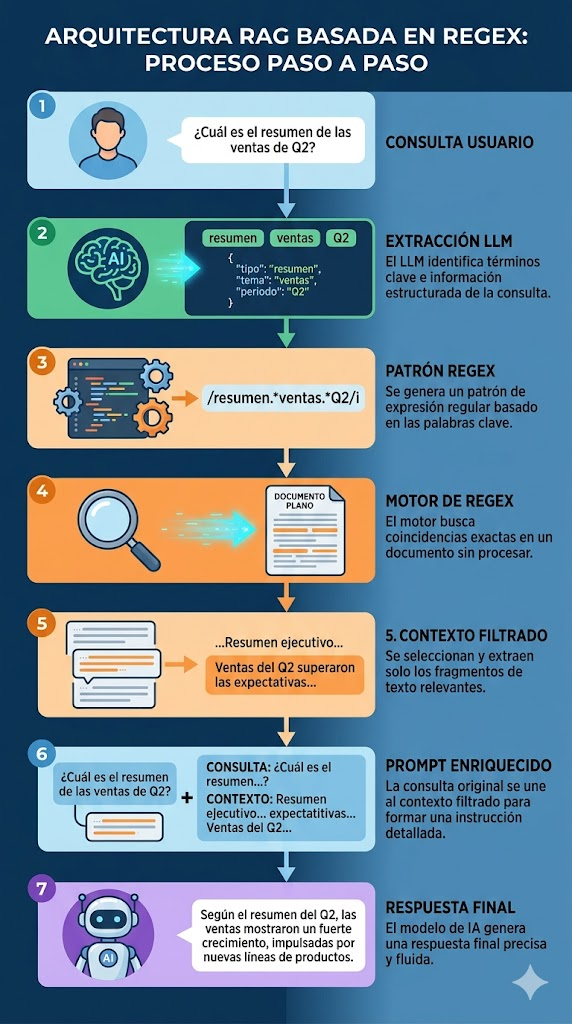




Como se puede apreciar no hay grandes cambios en la logica de trabajo con las tecnicas antes vistas.


>>IMPORTANTE
*Cuándo NO usar regex*
preguntas abiertas (“qué dice este documento”)
textos largos sin estructura
consultas semánticas
lenguaje natural libre

Un ejemplo de un RAG con Regex se puede ejecutar y ver en:

[01_LLM_RAG_con_REGEX](https://colab.research.google.com/drive/1d5-H-EIPo62MQ0WLRjiSCEm9KsdoHudA?usp=sharing)


Este codigo permite ver como se puede hacer un RAG muy simple usando un texto plano como base de conocimiento.

Esta estructura puede tener muchas otras formas de llevarse a cabo, usando un archivo de texto aparte, se suele definir secciones de texto con delimitadores especificos (algunas veces caracteres, palabras claves, saltos de linea, puntos, etc). Este proceso se lo conoce como chunking, que es separar los datos en estructuras de informacion mas pequeñas para evitar pasar al modelo un volumen de información muy grande e innecesario.


______________
>Si te quedan preguntas no dudes en contactarme

>>>arielmeragelman@gmail.com

>>>Lic. Sebastian A. Meragelman